<a href="https://colab.research.google.com/github/xmessi08/ML-project-7/blob/main/ML_project7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ ===
{'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Accuracy (дефолт): 0.9467 | Accuracy (подбор): 0.9400
F1-Score (дефолт): 0.9467 | F1-Score (подбор): 0.9408



/tmp/ipykernel_1117/1919551275.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


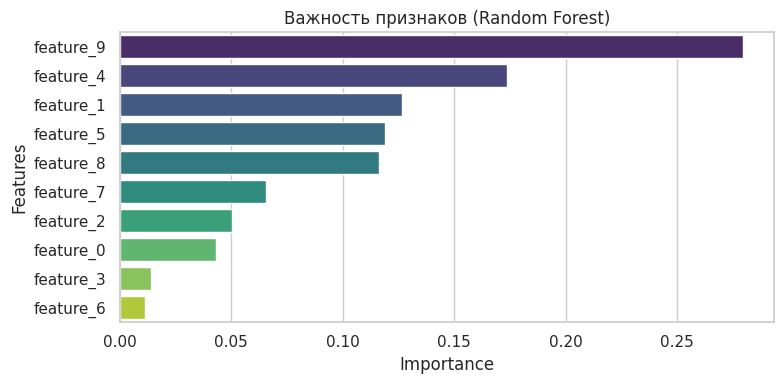

=== РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА ===
Удаленные признаки: ['feature_7', 'feature_2', 'feature_0', 'feature_3', 'feature_6']
F1-Score (все признаки):      0.9408
F1-Score (только топ-признаки): 0.9439


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

sns.set_theme(style="whitegrid")

# 1. ГЕНЕРАЦИЯ ДАТАСЕТА
X_raw, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=3,
    n_repeated=0, random_state=42
)
feature_names = [f'feature_{i}' for i in range(10)]
X = pd.DataFrame(X_raw, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. МОДЕЛЬ ПО УМОЛЧАНИЮ
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

y_pred_def = rf_default.predict(X_test)
acc_def = accuracy_score(y_test, y_pred_def)
f1_def = f1_score(y_test, y_pred_def)

# 3. ПОДБОР ГИПЕРПАРАМЕТРОВ ЧЕРЕЗ GRIDSEARCHCV (КРОСС-ВАЛИДАЦИЯ = 5)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

rf_best = grid_search.best_estimator_
y_pred_best = rf_best.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print("=== ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ ===")
print(grid_search.best_params_)
print(f"Accuracy (дефолт): {acc_def:.4f} | Accuracy (подбор): {acc_best:.4f}")
print(f"F1-Score (дефолт): {f1_def:.4f} | F1-Score (подбор): {f1_best:.4f}\n")

# 4. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ (FEATURE IMPORTANCES)
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Важность признаков (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 5. ЭКСПЕРИМЕНТ: УДАЛЕНИЕ НАИМЕНЕЕ ВАЖНЫХ ПРИЗНАКОВ
k_top = len(feature_names) // 2
top_features = importances.head(k_top).index.tolist()
removed_features = importances.tail(len(feature_names) - k_top).index.tolist()

X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

rf_reduced = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_reduced.fit(X_train_reduced, y_train)

y_pred_red = rf_reduced.predict(X_test_reduced)
acc_red = accuracy_score(y_test, y_pred_red)
f1_red = f1_score(y_test, y_pred_red)

print("=== РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА ===")
print(f"Удаленные признаки: {removed_features}")
print(f"F1-Score (все признаки):      {f1_best:.4f}")
print(f"F1-Score (только топ-признаки): {f1_red:.4f}")